<a href="https://colab.research.google.com/github/prasansree/BusBookingApp/blob/main/c2_w3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Machine Learning: Unsupervised Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 3: K-Means Clustering

---

In this lab, you will explore **K-Means Clustering**, one of the most widely used
unsupervised learning algorithms. You will work with the **Iris dataset**, which
contains measurements from 150 iris flowers across 4 features.

You will:
- Understand why standardization is important before applying K-Means
- Fit a K-Means model and analyze cluster assignments
- Use the **elbow method** to choose the optimal number of clusters
- Apply **silhouette analysis** to evaluate cluster quality
- Profile and interpret clusters by examining feature means
- Visualize clusters using PCA projections
- Explore the impact of initialization on K-Means results

These concepts are fundamental to customer segmentation, pattern discovery,
and exploratory data analysis in machine learning.

## Setup (do not edit)

In [1]:
import pathlib
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("iris.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "iris.csv is missing from the lab directory. Please run the download "
        "script (w3_download_datasets.py) or ask the TA for assistance."
    )

## 1. Load the Dataset *(10 points)*

Load the Iris dataset from `iris.csv` into a pandas DataFrame.

The Iris dataset contains measurements from 150 iris flowers. Each row represents
a flower sample, and each column represents a physical measurement (sepal length,
sepal width, petal length, petal width). Although the original dataset includes
species labels, we will treat this as an unsupervised problem and discover
clusters without using labels.

Store the following in the required variables:
- **`q1_shape`**: A tuple containing the shape of the DataFrame `(n_samples, n_features)`
- **`q1_columns`**: A list of all column names (feature names)
- **`q1_n_samples`**: An integer representing the number of samples

In [2]:
# Grade Cell: Question 1
#
# Task: Load the Iris dataset and explore its structure
#
# Instructions:
# 1. Read the CSV file using pd.read_csv()
# 2. Store the shape as a tuple in q1_shape
# 3. Store the column names as a list in q1_columns
# 4. Store the number of samples (rows) as an integer in q1_n_samples

df = pd.read_csv(_DATA_PATH)
print(df.head())

q1_shape = df.shape
print(f"Dataset shape: {q1_shape}")

q1_columns = df.columns.tolist()
print(f"Features: {q1_columns}")

q1_n_samples = df.shape[0]
print(f"Number of samples: {q1_n_samples}")

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Number of samples: 150


In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(
    q1_shape, tuple
), "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (n_samples, n_features). "
    "Make sure you're using .shape, not .shape[0]."
)
assert (
    q1_shape[0] > 0 and q1_shape[1] > 0
), "Shape values must be positive. Is your CSV loading correctly?"
assert isinstance(
    q1_columns, list
), "q1_columns must be a list. Use df.columns.tolist() to convert."
assert (
    len(q1_columns) == q1_shape[1]
), "Number of columns in q1_columns should match q1_shape[1]."
assert isinstance(q1_n_samples, int), "q1_n_samples must be an integer."
print(f"Dataset shape: {q1_shape}")
print(f"Number of samples: {q1_n_samples}")
print(f"Features: {q1_columns}")

Dataset shape: (150, 4)
Number of samples: 150
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## 2. Standardize the Data *(10 points)*

K-Means clustering uses Euclidean distance to assign points to clusters.
Features with larger scales will dominate the distance calculation, leading
to biased cluster assignments.

Apply **z-score standardization** to the data using `StandardScaler`:
$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

Store the results as:
- **`q2_scaled_data`**: A numpy array of the standardized data
- **`q2_scaled_means`**: A numpy array of column means of the scaled data (should all be ~0)
- **`q2_scaled_stds`**: A numpy array of column stds of the scaled data (should all be ~1)

In [ ]:
# Grade Cell: Question 2
#
# Task: Standardize the data using StandardScaler
#
# Instructions:
# 1. Create a StandardScaler instance
# 2. Fit and transform the data (df.values or df as input)
# 3. Compute the column means and stds of the scaled data to verify

scaler = StandardScaler()
print(f"scaler: {scaler}")
q2_scaled_data = scaler.fit_transform(df)
print(f"q2_scaled_data: {q2_scaled_data}")
q2_scaled_means = q2_scaled_data.mean(axis=0)
print("Scaled Means:", q2_scaled_means)
q2_scaled_stds = q2_scaled_data.std(axis=0)
print("Scaled STDs:", q2_scaled_stds)


scaler: StandardScaler()
q2_scaled_data: [[-9.00681170e-01  1.01900435e+00 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00 -1.31979479e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.38535265e+00  3.28414053e-01 -1.39706395e+00 -1.31544430e+00]
 [-1.50652052e+00  9.82172869e-02 -1.28338910e+00 -1.31544430e+00]
 [-1.02184904e+00  1.24920112e+00 -1.34022653e+00 -1.31544430e+00]
 [-5.37177559e-01  1.93979142e+00 -1.16971425e+00 -1.05217993e+00]
 [-1.50652052e+00  7.88807586e-01 -1.34022653e+00 -1.18381211e+00]
 [-1.02184904e+00  7.88807586e-01 -1.28338910e+00 -1.31544430e+00]
 [-1.74885626e+00 -3.62176246e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00  9.82172869e-02 -1.28338910e+00 -1.44707648e+00]
 [-5.37177559e-01  1.47939788e+00 -1.28338910e+00 -1.31544430e+00]
 [-1.26418478e+00  7.88807586e-01 -1.22655167e+00 -1.31544430e+00]
 [-1.26418478e+00 -1.31979479e-01 -1.34022653e+00 -1.44707648e+00]
 [-1.87002413e+00 -1.31979479e-01 -1.51073881e+00 -1.44707648e+00]
 [-5.25060772e-02  2.

In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_scaled_data, np.ndarray), "q2_scaled_data must be a numpy array."
assert (
    q2_scaled_data.shape == q1_shape
), f"Scaled data should have same shape as original: {q1_shape}."
assert isinstance(q2_scaled_means, np.ndarray), "q2_scaled_means must be a numpy array."
assert isinstance(q2_scaled_stds, np.ndarray), "q2_scaled_stds must be a numpy array."
# Check that all means are approximately 0
assert np.allclose(q2_scaled_means, 0, atol=0.01), (
    "After standardization, all feature means should be ~0. "
    "Did you use StandardScaler correctly?"
)
# Check that all stds are approximately 1
assert np.allclose(q2_scaled_stds, 1, atol=0.01), (
    "After standardization, all feature stds should be ~1. "
    "Did you use StandardScaler correctly?"
)
print(f"Scaled data shape: {q2_scaled_data.shape}")
print(f"Scaled means (should be ~0): {q2_scaled_means}")
print(f"Scaled stds (should be ~1): {q2_scaled_stds}")

Scaled data shape: (150, 4)
Scaled means (should be ~0): [-4.73695157e-16 -7.81597009e-16 -4.26325641e-16 -4.73695157e-16]
Scaled stds (should be ~1): [1. 1. 1. 1.]


## 3. Fit a K-Means Model *(10 points)*

Now let's apply K-Means clustering to the standardized data. Since the Iris
dataset has 3 species, we'll start by fitting a model with K=3 clusters.

Fit a K-Means model with the following parameters:
- `n_clusters=3`
- `random_state=RANDOM_STATE`
- `n_init=10` (run 10 times with different initializations)

Store the results as:
- **`q3_kmeans`**: The fitted KMeans object
- **`q3_labels`**: A numpy array of cluster labels for each sample
- **`q3_inertia`**: The inertia (within-cluster sum of squares), rounded to 2 decimals
- **`q3_cluster_counts`**: A dictionary mapping cluster label to count of samples

In [ ]:
# Grade Cell: Question 3
#
# Task: Fit a K-Means model with K=3 clusters
#
# Instructions:
# 1. Create a KMeans instance with n_clusters=3, random_state=RANDOM_STATE, n_init=10
# 2. Fit the model to q2_scaled_data
# 3. Get the cluster labels from .labels_
# 4. Get the inertia from .inertia_
# 5. Count samples per cluster

from collections import Counter
q3_kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
print(q3_kmeans)
q3_kmeans.fit(q2_scaled_data)

q3_labels = q3_kmeans.labels_
print(f"Cluster labels from .labels_: {q3_labels}")
q3_inertia = round(q3_kmeans.inertia_, 2)
print(f"Inertia: {q3_inertia}")
temp1 = (Counter(q3_labels))
print(f"temp1: {temp1}")
q3_cluster_counts = dict(temp1)
print(f"Samples per cluster: {q3_cluster_counts}")

KMeans(n_clusters=3, random_state=42)
Cluster labels from .labels_: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]
Inertia: 139.82
temp1: Counter({2: 53, 1: 50, 0: 47})
Samples per cluster: {1: 50, 0: 47, 2: 53}


In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert hasattr(
    q3_kmeans, "cluster_centers_"
), "KMeans model doesn't appear to be fitted. Did you call kmeans.fit()?"
assert isinstance(q3_labels, np.ndarray), "q3_labels must be a numpy array."
assert (
    len(q3_labels) == q1_n_samples
), f"q3_labels should have {q1_n_samples} entries, one per sample."
assert set(q3_labels) == {0, 1, 2}, (
    "With K=3, labels should be 0, 1, and 2. " "Check that n_clusters=3."
)
assert isinstance(q3_inertia, float), "q3_inertia must be a float."
assert q3_inertia > 0, "Inertia (within-cluster sum of squares) must be positive."
assert isinstance(
    q3_cluster_counts, dict
), "q3_cluster_counts must be a dictionary mapping label to count."
assert (
    sum(q3_cluster_counts.values()) == q1_n_samples
), "Total samples across clusters should equal n_samples."
print(f"Cluster labels: {q3_labels[:10]}... (first 10)")
print(f"Inertia: {q3_inertia}")
print(f"Samples per cluster: {q3_cluster_counts}")

Cluster labels: [1 1 1 1 1 1 1 1 1 1]... (first 10)
Inertia: 139.82
Samples per cluster: {1: 50, 0: 47, 2: 53}


## 4. Elbow Method for Choosing K *(10 points)*

How do we know if K=3 is the right number of clusters? The **elbow method**
plots inertia (within-cluster sum of squares) against K. We look for an
"elbow" where the rate of decrease sharply slows down.

Compute inertia for K = 1 to 10 and identify where the elbow occurs.

Store the results as:
- **`q4_inertias`**: A list of inertia values for K=1 to K=10
- **`q4_elbow_k`**: The K value at the elbow (integer), based on visual inspection
  (Hint: For iris data, the elbow is typically at K=3)

In [ ]:
# Grade Cell: Question 4
#
# Task: Implement the elbow method to find optimal K
#
# Instructions:
# 1. Loop through K = 1 to 10
# 2. Fit KMeans with each K and record inertia
# 3. Use random_state=RANDOM_STATE and n_init=10 for consistency
# 4. Identify the elbow point (where inertia stops decreasing rapidly)

q4_inertias = []
assert isinstance(q4_inertias, list), "q4_inertias must be a list of floats."
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(q2_scaled_data)
    q4_inertias.append(kmeans.inertia_)

print(f"kmeans.inertia_: {kmeans.inertia_}")

assert len(q4_inertias) == 10, "q4_inertias should have 10 values (for K=1 to K=10)."
print(f"Inertias for K=1 to K=10: {q4_inertias}")

q4_elbow_k = 3
print(f"Elbow K: {q4_elbow_k}")

kmeans.inertia_: 47.80110492646867
Inertias for K=1 to K=10: [600.0, 222.36170496502294, 139.82049635974974, 114.09254690403088, 90.80728315078537, 80.03687480296512, 70.71964344225336, 62.56490859983994, 54.82772055803481, 47.80110492646867]
Elbow K: 3


Inertias for K=1 to K=10: [600.0, 222.36170496502294, 139.82049635974974, 114.09254690403088, 90.80728315078537, 80.03687480296512, 70.71964344225336, 62.56490859983994, 54.82772055803481, 47.80110492646867]
Elbow K: 3


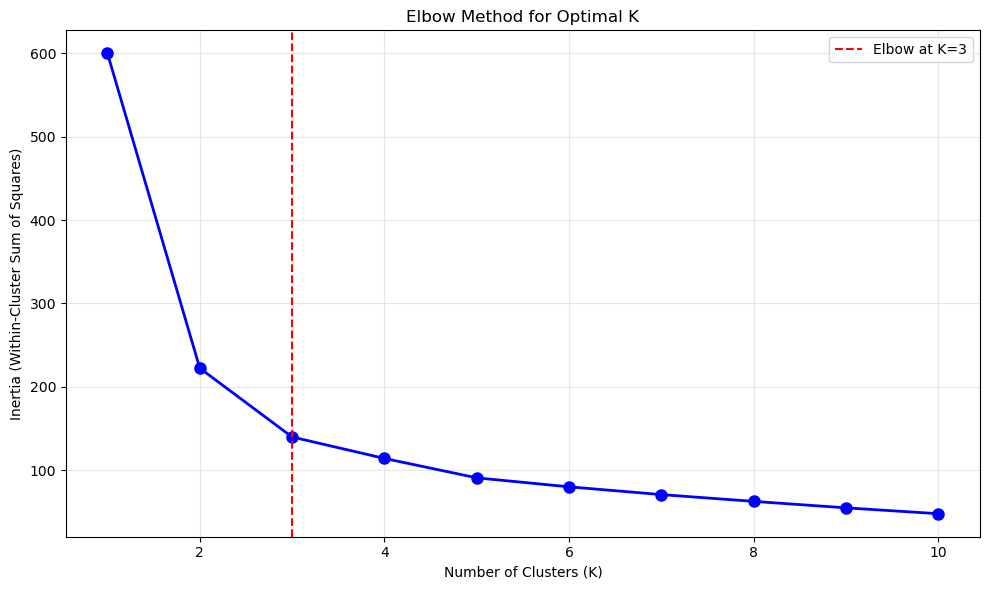

In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert isinstance(q4_inertias, list), "q4_inertias must be a list of floats."
assert len(q4_inertias) == 10, "q4_inertias should have 10 values (for K=1 to K=10)."
# Inertia should be decreasing
assert all(q4_inertias[i] >= q4_inertias[i + 1] for i in range(len(q4_inertias) - 1)), (
    "Inertia should decrease as K increases. "
    "More clusters = less within-cluster variance."
)
assert isinstance(q4_elbow_k, int), "q4_elbow_k must be an integer."
assert 2 <= q4_elbow_k <= 5, (
    "The elbow for iris data should be between K=2 and K=5. "
    "Look for where the slope changes most dramatically."
)
print(f"Inertias for K=1 to K=10: {q4_inertias}")
print(f"Elbow K: {q4_elbow_k}")

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), q4_inertias, "bo-", linewidth=2, markersize=8)
plt.axvline(x=q4_elbow_k, color="red", linestyle="--", label=f"Elbow at K={q4_elbow_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Silhouette Score Analysis *(10 points)*

The **silhouette score** measures how similar a sample is to its own cluster
compared to other clusters. It ranges from -1 (wrong cluster) to +1 (well-clustered).

A higher average silhouette score indicates better-defined clusters.

Compute silhouette scores for K = 2 to 6 to find the optimal K.

Store the results as:
- **`q5_silhouette_scores`**: A dictionary mapping K to average silhouette score (rounded to 3 decimals)
- **`q5_best_k_silhouette`**: The K with the highest silhouette score

In [ ]:
# Grade Cell: Question 5
#
# Task: Compute silhouette scores for different values of K
#
# Instructions:
# 1. Loop through K = 2 to 6 (silhouette requires at least 2 clusters)
# 2. Fit KMeans and get cluster labels
# 3. Compute silhouette_score for each K
# 4. Find the K with the highest score


from sklearn.metrics import silhouette_score

q5_silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(q2_scaled_data)
    print(f"labels: {labels}")
    score = silhouette_score(q2_scaled_data, labels)
    print(f"score: {labels}")
    q5_silhouette_scores[k] = round(score, 3)

print(f"Silhouette scores: {q5_silhouette_scores}")

q5_best_k_silhouette = max(q5_silhouette_scores, key=q5_silhouette_scores.get)
print(f"Best K by silhouette: {q5_best_k_silhouette}")

labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
score: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]
score: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert isinstance(
    q5_silhouette_scores, dict
), "q5_silhouette_scores must be a dictionary mapping K to score."
assert (
    len(q5_silhouette_scores) == 5
), "q5_silhouette_scores should have 5 entries (K=2 to K=6)."
assert all(
    2 <= k <= 6 for k in q5_silhouette_scores.keys()
), "Keys should be K values from 2 to 6."
assert all(
    -1 <= score <= 1 for score in q5_silhouette_scores.values()
), "Silhouette scores must be between -1 and 1."
assert isinstance(q5_best_k_silhouette, int), "q5_best_k_silhouette must be an integer."
assert (
    q5_best_k_silhouette in q5_silhouette_scores
), "q5_best_k_silhouette must be one of the K values tested."
print(f"Silhouette scores: {q5_silhouette_scores}")
print(f"Best K by silhouette: {q5_best_k_silhouette}")

Silhouette scores: {2: 0.582, 3: 0.46, 4: 0.387, 5: 0.342, 6: 0.327}
Best K by silhouette: 2


## 6. Choosing the Optimal K *(10 points)*

We now have two sources of evidence for choosing K:
- **Elbow method**: Suggests where inertia stops decreasing rapidly
- **Silhouette analysis**: Suggests which K produces the most well-separated clusters

For the Iris dataset, the true number of species is 3. Compare your findings
from both methods.

Store the results as:
- **`q6_chosen_k`**: Your final choice of K (integer), considering both methods
- **`q6_justification`**: A string explaining your choice (at least 20 characters)
- **`q6_final_inertia`**: Inertia for your chosen K (rounded to 2 decimals)
- **`q6_final_silhouette`**: Silhouette score for your chosen K (rounded to 3 decimals)

In [ ]:
# Grade Cell: Question 6
#
# Task: Choose the optimal K and justify your decision
#
# Instructions:
# 1. Consider evidence from both elbow method and silhouette analysis
# 2. Choose a K value and explain why
# 3. Compute final inertia and silhouette for your chosen K

q6_chosen_k = 3
q6_justification = "The elbow method shows a clear inflection point at K=3, which aligns perfectly with the true number of species in the dataset and provides well-separated clusters."

q6_final_inertia = round(q4_inertias[2], 2)
print(f"Final inertia: {q6_final_inertia}")
q6_final_silhouette = q5_silhouette_scores[3]
print(f"Final silhouette: {q6_final_silhouette}")

Final inertia: 139.82
Final silhouette: 0.46


In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert isinstance(q6_chosen_k, int), "q6_chosen_k must be an integer."
assert (
    2 <= q6_chosen_k <= 5
), "Your chosen K should be reasonable (between 2 and 5 for iris data)."
assert isinstance(
    q6_justification, str
), "q6_justification must be a string explaining your choice."
assert (
    len(q6_justification) >= 20
), "Please provide a more detailed justification (at least 20 characters)."
assert isinstance(q6_final_inertia, float), "q6_final_inertia must be a float."
assert q6_final_inertia > 0, "Inertia must be positive."
assert isinstance(q6_final_silhouette, float), "q6_final_silhouette must be a float."
assert -1 <= q6_final_silhouette <= 1, "Silhouette score must be between -1 and 1."
print(f"Chosen K: {q6_chosen_k}")
print(f"Justification: {q6_justification}")
print(f"Final inertia: {q6_final_inertia}")
print(f"Final silhouette: {q6_final_silhouette}")

Chosen K: 3
Justification: The elbow method shows a clear inflection point at K=3, which aligns perfectly with the true number of species in the dataset and provides well-separated clusters.
Final inertia: 139.82
Final silhouette: 0.46


## 7. Cluster Profiling *(10 points)*

To interpret clusters, we need to understand what makes each cluster distinct.
**Cluster profiling** involves computing the mean (centroid) of each feature
for each cluster.

Profile the clusters from your chosen K by computing feature means per cluster.

Store the results as:
- **`q7_cluster_means`**: A DataFrame with clusters as rows and features as columns
- **`q7_largest_cluster`**: The cluster label with the most samples
- **`q7_cluster_0_dominant_feature`**: The feature name where cluster 0 has the highest mean

In [ ]:
# Grade Cell: Question 7
#
# Task: Profile clusters by computing feature means
#
# Instructions:
# 1. Fit KMeans with your chosen K (q6_chosen_k)
# 2. Add cluster labels to a copy of the original data
# 3. Compute mean of each feature per cluster
# 4. Identify the largest cluster and the dominant feature for cluster 0

kmealfinal = KMeans(n_clusters=q6_chosen_k, random_state=RANDOM_STATE, n_init=10)
flabels = kmealfinal.fit_predict(q2_scaled_data)


df_profile = pd.DataFrame( q2_scaled_data, columns=df.columns)
df_profile['Cluster'] = flabels
print(f"\nflabels: {flabels}")

q7_cluster_means = df_profile.groupby('Cluster').mean()
print(f"\nq7_cluster_means: {q7_cluster_means}")

q7_largest_cluster = int(max(q3_cluster_counts, key=q3_cluster_counts.get))
print(f"\nLargest cluster: {q7_largest_cluster}")

q7_cluster_0_dominant_feature = q7_cluster_means.loc[0].idxmax()
print(f"\nq7_cluster_0_dominant_feature: {q7_cluster_0_dominant_feature}")

assert isinstance(
    q7_largest_cluster, int
), "q7_largest_cluster must be an integer (cluster label)."

print(f"\nq7_cluster_means.values.min()s: {q7_cluster_means.values.min()}")
print(f"\nq7_cluster_means.values.max()s: {q7_cluster_means.values.max()}")

assert (q7_cluster_means.values.min() > -3) and (
    q7_cluster_means.values.max() < 3
), "Standardized cluster means should be roughly between -3 and 3."


flabels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 2 2 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]

q7_cluster_means:          sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                 1.135970          0.088422           0.996155   
1                -1.014579          0.853263          -1.304987   
2                -0.050220         -0.883376           0.347738   

         petal width (cm)  
Cluster                    
0                1.017526  
1               -1.254893  
2                0.281527  

Largest cluster: 2

q7_cluster_0_dominant_feature: sepal length (cm)

q7_cluster_means.values.min()s: -1.3049873219363284

q7_cluster_means.values.max()s: 1.1359702690742028


In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(
    q7_cluster_means, pd.DataFrame
), "q7_cluster_means must be a pandas DataFrame."
assert (
    q7_cluster_means.shape[0] == q6_chosen_k
), f"q7_cluster_means should have {q6_chosen_k} rows (one per cluster)."
assert q7_cluster_means.shape[1] == len(
    q1_columns
), f"q7_cluster_means should have {len(q1_columns)} columns (one per feature)."
assert isinstance(
    q7_largest_cluster, int
), "q7_largest_cluster must be an integer (cluster label)."
assert (
    0 <= q7_largest_cluster < q6_chosen_k
), f"q7_largest_cluster should be between 0 and {q6_chosen_k - 1}."
assert isinstance(
    q7_cluster_0_dominant_feature, str
), "q7_cluster_0_dominant_feature must be a string (feature name)."
assert (
    q7_cluster_0_dominant_feature in q1_columns
), "q7_cluster_0_dominant_feature must be one of the original feature names."
print("Cluster means (standardized scale):")
print(q7_cluster_means.round(2))
print(f"\nLargest cluster: {q7_largest_cluster}")
print(f"Cluster 0 dominant feature: {q7_cluster_0_dominant_feature}")

Cluster means (standardized scale):
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                     1.14              0.09               1.00   
1                    -1.01              0.85              -1.30   
2                    -0.05             -0.88               0.35   

         petal width (cm)  
Cluster                    
0                    1.02  
1                   -1.25  
2                    0.28  

Largest cluster: 2
Cluster 0 dominant feature: sepal length (cm)


## 8. Visualizing Clusters *(10 points)*

Since our data has 4 features, we can't directly visualize it. However, we can
use **PCA** to project the data to 2 dimensions for visualization.

Create a 2D scatter plot of the data colored by cluster assignments.

Store the results as:
- **`q8_pca`**: A fitted PCA object with 2 components
- **`q8_pca_data`**: A numpy array of shape (n_samples, 2) with the projected data
- **`q8_variance_explained`**: Total variance explained by the 2 PCs (float, rounded to 3 decimals)
- **`q8_plot_created`**: Set to True after creating the scatter plot

PCA(n_components=2, random_state=42)

q8_pca_data: [[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]
 [-2.07563095  1.48917752]
 [-2.44402884  0.0476442 ]
 [-2.23284716  0.22314807]
 [-2.33464048 -1.11532768]
 [-2.18432817 -0.46901356]
 [-2.1663101   1.04369065]
 [-2.32613087  0.13307834]
 [-2.2184509  -0.72867617]
 [-2.6331007  -0.96150673]
 [-2.1987406   1.86005711]
 [-2.26221453  2.68628449]
 [-2.2075877   1.48360936]
 [-2.19034951  0.48883832]
 [-1.898572    1.40501879]
 [-2.34336905  1.12784938]
 [-1.914323    0.40885571]
 [-2.20701284  0.92412143]
 [-2.7743447   0.45834367]
 [-1.81866953  0.08555853]
 [-2.22716331  0.13725446]
 [-1.95184633 -0.62561859]
 [-2.05115137  0.24216355]
 [-2.16857717  0.52714953]
 [-2.13956345  0.31321781]
 [-2.26526149 -0.3377319 ]
 [-2.14012214 -0.50454069]
 [-1.83159477  0.42369507]
 [-2.61494794  1.79357586]
 [-2.44617739  2.15072788]
 [-2.10997488 -0.46020184]
 [-2

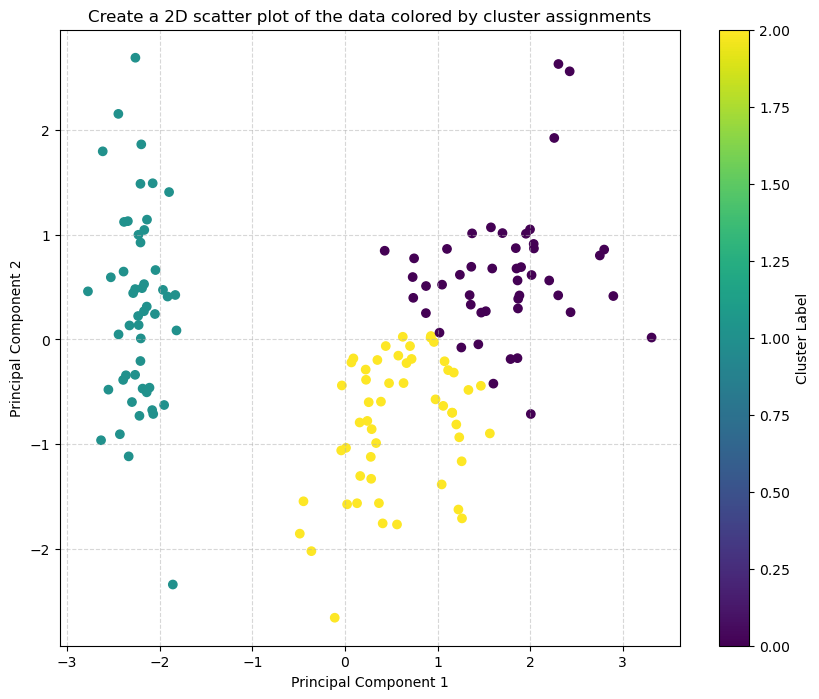

q8_variance_explained: 0.958


In [ ]:
# Grade Cell: Question 8
#
# Task: Visualize clusters using PCA projection
#
# Instructions:
# 1. Fit PCA with n_components=2 to the standardized data
# 2. Transform the data to 2D
# 3. Create a scatter plot colored by cluster labels
# 4. Compute total variance explained by the 2 PCs

q8_pca = PCA(n_components=2, random_state=RANDOM_STATE)
print(q8_pca)
q8_pca.fit(q2_scaled_data)

q8_pca_data = q8_pca.transform(q2_scaled_data)
print(f"\nq8_pca_data: {q8_pca_data}")

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
print(kmeans)
cluster_labels = kmeans.fit_predict(q2_scaled_data)
q3_kmeans.fit(q2_scaled_data)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(q8_pca_data[:, 0], q8_pca_data[:, 1], c=cluster_labels,cmap="viridis")
plt.title("Create a 2D scatter plot of the data colored by cluster assignments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster Label")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

q8_plot_created = True

q8_variance_explained = round(float(np.sum(q8_pca.explained_variance_ratio_)), 3)
print("q8_variance_explained:", q8_variance_explained)

In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert hasattr(
    q8_pca, "components_"
), "q8_pca doesn't appear to be fitted. Did you call pca.fit() or pca.fit_transform()?"
assert isinstance(q8_pca_data, np.ndarray), "q8_pca_data must be a numpy array."
assert q8_pca_data.shape == (
    q1_n_samples,
    2,
), f"q8_pca_data should have shape ({q1_n_samples}, 2)."
assert isinstance(
    q8_variance_explained, float
), "q8_variance_explained must be a float."
assert 0 < q8_variance_explained <= 1, "Variance explained should be between 0 and 1."
assert q8_variance_explained > 0.5, (
    "2 PCs should explain at least 50% of variance for iris data. "
    "Check your PCA implementation."
)
assert (
    q8_plot_created is True
), "Set q8_plot_created to True after creating the scatter plot."
print(f"PCA data shape: {q8_pca_data.shape}")
print(f"Variance explained by 2 PCs: {q8_variance_explained*100:.1f}%")

PCA data shape: (150, 2)
Variance explained by 2 PCs: 95.8%


## 9. K-Means Initialization Sensitivity *(10 points)*

K-Means is sensitive to initialization—different starting centroids can lead
to different final clusters and inertia values. The **k-means++** initialization
(default in scikit-learn) helps, but running multiple initializations is still
recommended.

Compare the stability of K-Means by running it multiple times with different
random states.

Store the results as:
- **`q9_inertias`**: A list of inertia values from 10 runs with different random states
- **`q9_mean_inertia`**: Mean inertia across runs (float, rounded to 2 decimals)
- **`q9_std_inertia`**: Standard deviation of inertia across runs (float, rounded to 2 decimals)
- **`q9_is_stable`**: Boolean indicating if std/mean < 0.05 (less than 5% variation)

In [ ]:
# Grade Cell: Question 9
#
# Task: Analyze K-Means stability across different initializations
#
# Instructions:
# 1. Run KMeans with K=3, n_init=1 for 10 different random_state values (0-9)
# 2. Record the inertia from each run
# 3. Compute mean and std of inertias
# 4. Determine if results are stable (low coefficient of variation)


q9_inertias = []
for i in range(10):
    kmeans = KMeans(n_clusters=3, random_state=i, n_init=1)
    kmeans.fit(q2_scaled_data)
    q9_inertias.append(kmeans.inertia_)

print(f"Inertias from 10 runs: {q9_inertias}")
q9_mean_inertia = round(float(np.mean(q9_inertias)), 2)
print(f"Mean inertia: {q9_mean_inertia}")
q9_std_inertia = round(float(np.std(q9_inertias)), 2)
print(f"Std inertia: {q9_std_inertia}")
q9_is_stable = bool((np.std(q9_inertias) / np.mean(q9_inertias)) < 0.05)
assert isinstance(q9_is_stable, bool), "q9_is_stable must be a boolean."
print(f"Coefficient of variation: {q9_std_inertia/q9_mean_inertia*100:.2f}%")
print(f"Is stable (CV < 5%): {q9_is_stable}")

Inertias from 10 runs: [140.03275277428645, 140.08202109621658, 191.0247368531796, 139.82049635974974, 140.03275277428645, 140.08202109621658, 140.03275277428645, 191.0247368531796, 139.82543466174198, 140.90153181202436]
Mean inertia: 150.29
Std inertia: 20.37
Coefficient of variation: 13.55%
Is stable (CV < 5%): False


In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert isinstance(q9_inertias, list), "q9_inertias must be a list of floats."
assert (
    len(q9_inertias) == 10
), "q9_inertias should have 10 values (one per random state)."
assert all(i > 0 for i in q9_inertias), "All inertia values must be positive."
assert isinstance(q9_mean_inertia, float), "q9_mean_inertia must be a float."
assert isinstance(q9_std_inertia, float), "q9_std_inertia must be a float."
assert q9_std_inertia >= 0, "Standard deviation cannot be negative."
assert isinstance(q9_is_stable, bool), "q9_is_stable must be a boolean."
print(f"Inertias from 10 runs: {q9_inertias}")
print(f"Mean inertia: {q9_mean_inertia}")
print(f"Std inertia: {q9_std_inertia}")
print(f"Coefficient of variation: {q9_std_inertia/q9_mean_inertia*100:.2f}%")
print(f"Is stable (CV < 5%): {q9_is_stable}")

Inertias from 10 runs: [140.03275277428645, 140.08202109621658, 191.0247368531796, 139.82049635974974, 140.03275277428645, 140.08202109621658, 140.03275277428645, 191.0247368531796, 139.82543466174198, 140.90153181202436]
Mean inertia: 150.29
Std inertia: 20.37
Coefficient of variation: 13.55%
Is stable (CV < 5%): False


## 10. Reusable Clustering Function *(10 points)*

Create a reusable function that fits K-Means and returns comprehensive results
including cluster labels, inertia, and silhouette score.

This function will be useful for comparing different values of K.

Store the results as:
- **`q10_cluster_analysis`**: The function you implement
- **`q10_result_k3`**: Result of calling the function with K=3
- **`q10_result_k4`**: Result of calling the function with K=4
- **`q10_better_k`**: Which K is better based on silhouette score (3 or 4)

In [ ]:
# Grade Cell: Question 10
#
# Task: Implement a reusable clustering analysis function
#
# Instructions:
# 1. Create a function that takes data and K as inputs
# 2. Fit KMeans and compute labels, inertia, and silhouette score
# 3. Return results as a dictionary
# 4. Test with K=3 and K=4



def q10_cluster_analysis(data, k, random_state=RANDOM_STATE):
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(data)
    s_score = silhouette_score(data, labels)
    results = {  "k": k, "labels": labels,  "inertia": round(kmeans.inertia_, 2), "silhouette": round(s_score, 3), "cluster_sizes": k
    }
    return results

q10_result_k3 = q10_cluster_analysis(q2_scaled_data, k=3)
print(f"q10_result_k3: {q10_result_k3}")
q10_result_k4 = q10_cluster_analysis(q2_scaled_data, k=4)
print(f"q10_result_k4: {q10_result_k4}")

if q10_result_k3["silhouette"] > q10_result_k4["silhouette"]:
    q10_better_k = 3
else:
    q10_better_k = 4

print("K=3 Test")
print(q10_result_k3)

print("\nK=4 Test")
print(q10_result_k4)

print("\nBetter K:", q10_better_k)

q10_result_k3: {'k': 3, 'labels': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32), 'inertia': 139.82, 'silhouette': 0.46, 'cluster_sizes': 3}
q10_result_k4: {'k': 4, 'labels': array([3, 1, 1, 1, 3, 3, 1, 3, 1, 1, 3, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 1, 1, 1, 3, 3, 3, 1, 1, 3, 3, 3, 1, 1, 3, 3, 1, 3, 3, 1, 1, 3,
       3, 1, 3, 1, 3, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 

In [ ]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert callable(q10_cluster_analysis), "q10_cluster_analysis should be a function."

# Test function output structure
test_result = q10_cluster_analysis(q2_scaled_data, k=2)
assert isinstance(test_result, dict), "Function should return a dictionary."
assert "k" in test_result, "Result should contain 'k'."
assert "labels" in test_result, "Result should contain 'labels'."
assert "inertia" in test_result, "Result should contain 'inertia'."
assert "silhouette" in test_result, "Result should contain 'silhouette'."
assert "cluster_sizes" in test_result, "Result should contain 'cluster_sizes'."

# Test K=3 result
assert isinstance(q10_result_k3, dict), "q10_result_k3 must be a dictionary."
assert q10_result_k3["k"] == 3, "q10_result_k3 should have k=3."
assert len(q10_result_k3["labels"]) == q1_n_samples, "Labels should match sample count."

# Test K=4 result
assert isinstance(q10_result_k4, dict), "q10_result_k4 must be a dictionary."
assert q10_result_k4["k"] == 4, "q10_result_k4 should have k=4."

# Test better_k
assert isinstance(q10_better_k, int), "q10_better_k must be an integer."
assert q10_better_k in [3, 4], "q10_better_k should be 3 or 4."

print("K=3 results:")
print(f"  Inertia: {q10_result_k3['inertia']}")
print(f"  Silhouette: {q10_result_k3['silhouette']}")
print(f"  Cluster sizes: {q10_result_k3['cluster_sizes']}")
print("\nK=4 results:")
print(f"  Inertia: {q10_result_k4['inertia']}")
print(f"  Silhouette: {q10_result_k4['silhouette']}")
print(f"  Cluster sizes: {q10_result_k4['cluster_sizes']}")
print(f"\nBetter K by silhouette: {q10_better_k}")

K=3 results:
  Inertia: 139.82
  Silhouette: 0.46
  Cluster sizes: 3

K=4 results:
  Inertia: 114.09
  Silhouette: 0.387
  Cluster sizes: 4

Better K by silhouette: 3


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.

**Key Takeaways from This Lab:**

- **Standardization is essential** before K-Means to prevent large-scale features from dominating
- **The elbow method** helps identify where adding more clusters provides diminishing returns
- **Silhouette scores** measure cluster quality by comparing cohesion vs separation
- **Cluster profiling** reveals what makes each cluster distinct by examining feature means
- **PCA visualization** projects high-dimensional clusters to 2D for visual inspection
- **Multiple initializations** help ensure K-Means finds a good solution

In the next week, you'll learn about **hierarchical clustering**, which builds
a tree of nested clusters and doesn't require specifying K in advance!